# Imports

In [37]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
from scipy.stats import pearsonr

# Functions

In [3]:
# Local helper function to save inside summary_outputs
def save_path(filename):
    return os.path.join(summary_dir, filename)

# Setup

In [30]:
base_dir = "uncertainty_runs"
variable_to_compare = "predictions"
disagreement_threshold = 0.05
epsilon = 1e-6  # for coefficient of variation to avoid division by zero

summary_dir = os.path.join(base_dir, "summary_outputs")
os.makedirs(summary_dir, exist_ok=True)

# time steps to plot
time_steps = [0,1,2]
single_time_step = time_steps[0]

# Load files

In [4]:
# Discover all sample_predictions_training.nc files inside uncertainty directory
nc_files = sorted(glob(os.path.join(base_dir, "*", "sample_predictions_training.nc")))
if not nc_files:
    raise FileNotFoundError(f"No .nc files found in {base_dir}")
print(f"Found {len(nc_files)} prediction files.")

# Load and stack predictions
datasets = [xr.open_dataset(f) for f in nc_files]
preds = xr.concat([ds[variable_to_compare] for ds in datasets], dim="seed")

Found 5 prediction files.


# Basic statistics

### Static stats for single timesteps

In [31]:
mean_pred = preds.mean(dim="seed")
std_pred = preds.std(dim="seed")
cv_pred = std_pred / (mean_pred + epsilon)
q_vals = preds.quantile([0.05, 0.95], dim="seed")
p5 = q_vals.sel(quantile=0.05).drop_vars("quantile")
p95 = q_vals.sel(quantile=0.95).drop_vars("quantile")
range_90 = p95 - p5

# Prediction disagreement zone (binary mask)
disagreement_mask = (range_90 > disagreement_threshold)

# Save summary statistics to NetCDF
summary_ds = xr.Dataset({
    "mean_prediction": mean_pred,
    "std_deviation": std_pred,
    "coefficient_of_variation": cv_pred,
    "percentile_5": p5,
    "percentile_95": p95,
    "range_90": range_90,
    "disagreement_zone": disagreement_mask.astype("int")  # Save as 0/1 binary mask
})
summary_ds.to_netcdf(save_path("uncertainty_summary_statistics.nc"))
print("Saved uncertainty_summary_statistics.nc")

Saved uncertainty_summary_statistics.nc


## Plot statistics

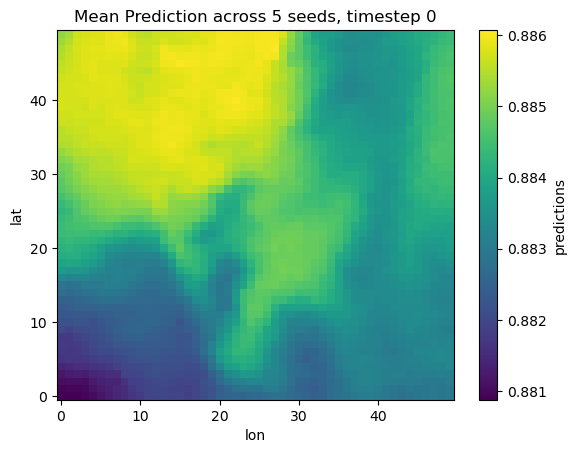

Saved Mean Prediction across 5 seeds, timestep 0.png


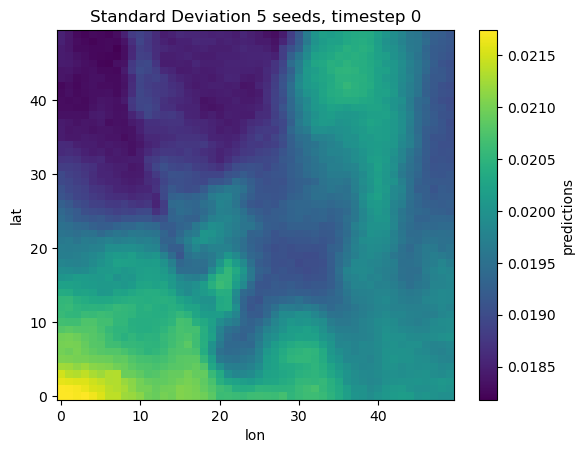

Saved Standard Deviation 5 seeds, timestep 0.png


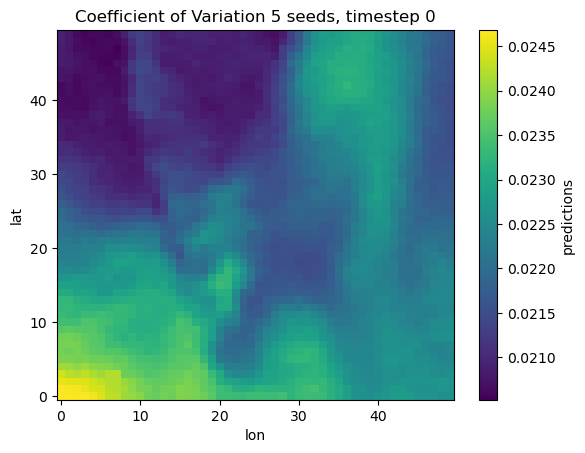

Saved Coefficient of Variation 5 seeds, timestep 0.png


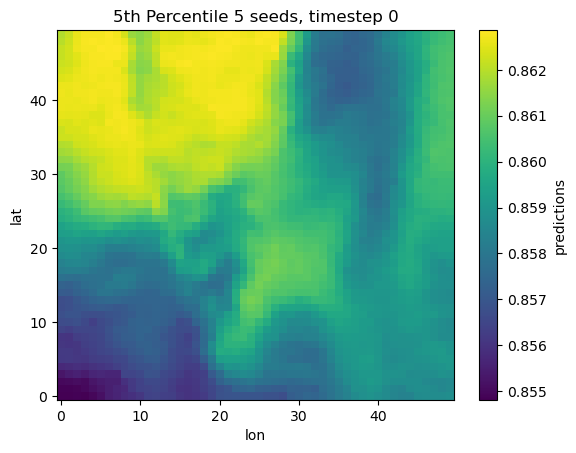

Saved 5th Percentile 5 seeds, timestep 0.png


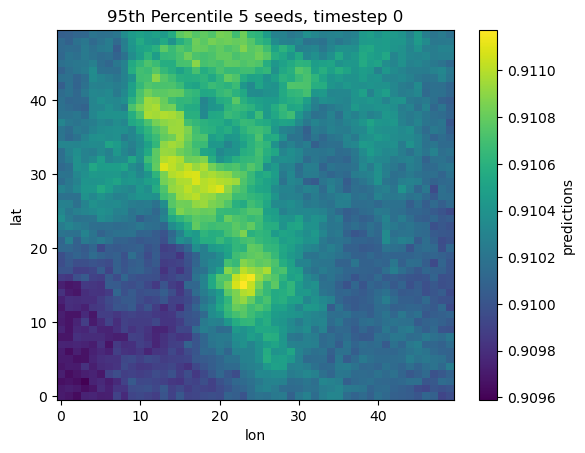

Saved 95th Percentile 5 seeds, timestep 0.png


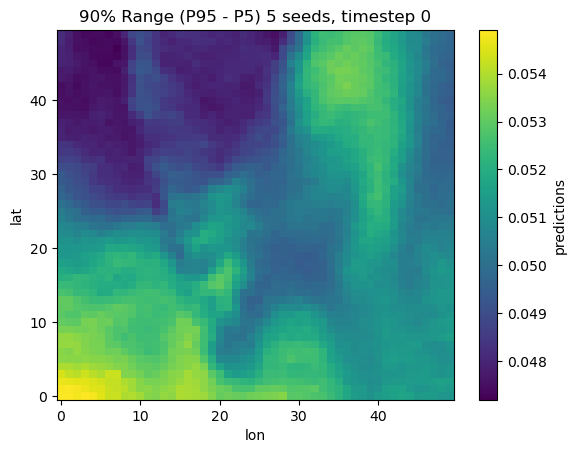

Saved 90% Range (P95 - P5) 5 seeds, timestep 0.png


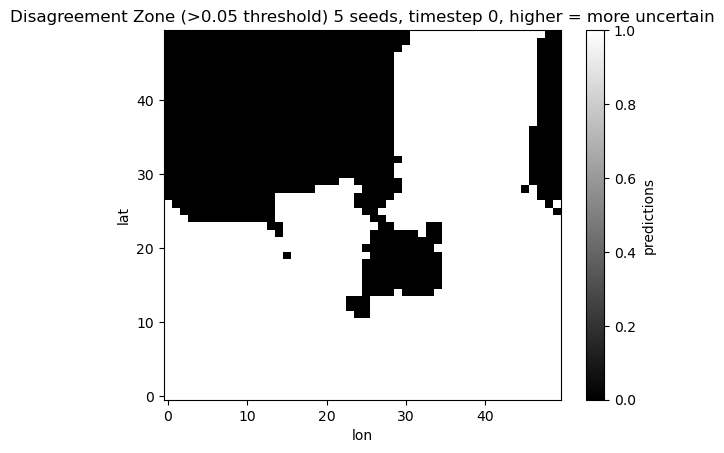

Saved Disagreement Zone (>0.05 threshold) 5 seeds, timestep 0, higher = more uncertain.png


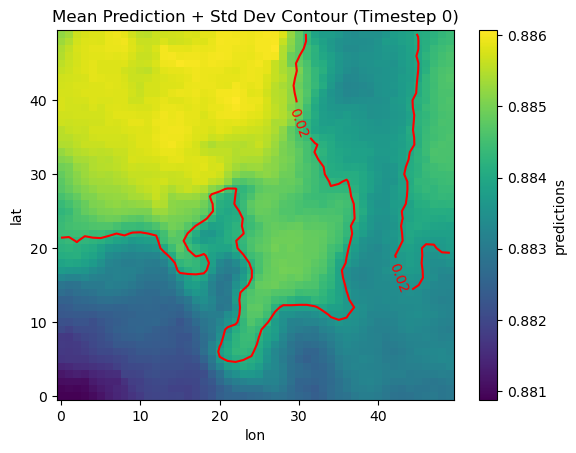

Saved mean_with_std_contour.png


In [33]:
# Plot basic metrics
plots = {
    f"Mean Prediction across {len(nc_files)} seeds, timestep {single_time_step}": mean_pred,
    f"Standard Deviation {len(nc_files)} seeds, timestep {single_time_step}": std_pred,
   f"Coefficient of Variation {len(nc_files)} seeds, timestep {single_time_step}" : cv_pred,
    f"5th Percentile {len(nc_files)} seeds, timestep {single_time_step}": p5,
    f"95th Percentile {len(nc_files)} seeds, timestep {single_time_step}": p95,
    f"90% Range (P95 - P5) {len(nc_files)} seeds, timestep {single_time_step}": range_90,
    f"Disagreement Zone (>{disagreement_threshold} threshold) {len(nc_files)} seeds, timestep {single_time_step}, higher = more uncertain": disagreement_mask.astype("int")
}

for name, data in plots.items():
    plt.figure()
    if "time" in data.dims:
        data = data.isel(time=single_time_step)
    data.plot(cmap="viridis" if "Zone" not in name else "gray")
    plt.title(name)
    plt.savefig(save_path(name.replace(" ", "_").lower() + ".png"))
    plt.show()
    plt.close()
    print(f"Saved {name}.png")

# Uncertainty-weighted visualisation (mean + contour of standard deviation)
plt.figure()
mean_pred.isel(time=0).plot(cmap="viridis")  # reduce to 2D
cs = plt.contour(std_pred.isel(time=time_steps[0]), levels=[std_pred.mean().item()], colors="red")
plt.clabel(cs, fmt="%.2f", colors="red")
plt.title("Mean Prediction + Std Dev Contour (Timestep 0)")
plt.savefig(save_path("mean_with_std_contour.png"))
plt.show()
plt.close()
print("Saved mean_with_std_contour.png")



# Histograms showing distributions of uncertainty metrics
histograms = {
    "Standard Deviation": std_pred.values.flatten(),
    "Coefficient of Variation": cv_pred.values.flatten(),
    "90% Prediction Range": range_90.values.flatten()
}


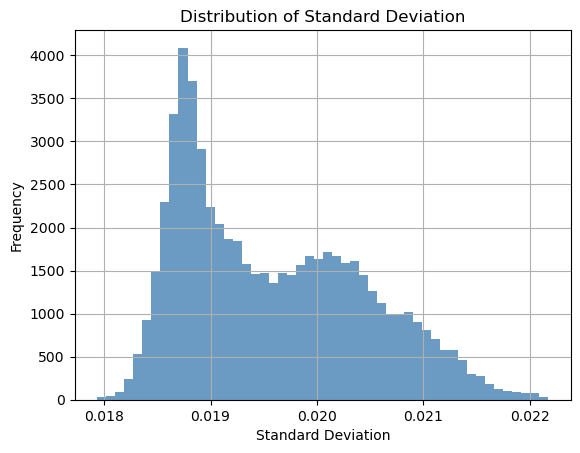

Saved hist_standard_deviation.png


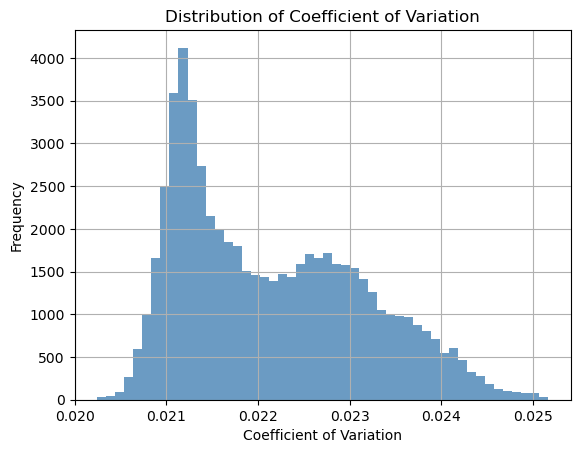

Saved hist_coefficient_of_variation.png


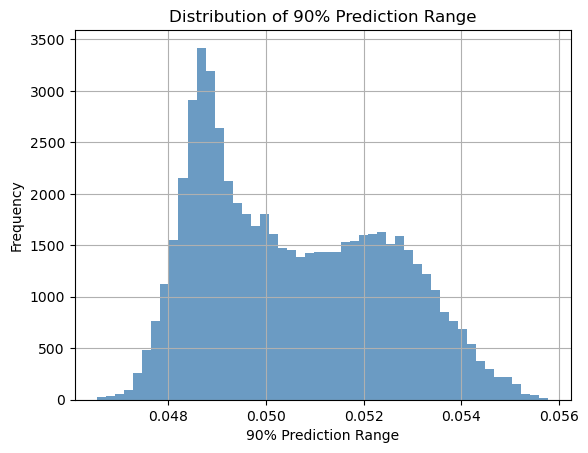

Saved hist_90%_prediction_range.png


In [20]:
# Histograms showing distributions of uncertainty metrics
histograms = {
    "Standard Deviation": std_pred.values.flatten(),
    "Coefficient of Variation": cv_pred.values.flatten(),
    "90% Prediction Range": range_90.values.flatten()
}


for name, values in histograms.items():
    plt.figure()
    plt.hist(values, bins=50, color="steelblue", alpha=0.8)
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid(True)
    filename = f"hist_{name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path(filename))
    plt.show()
    plt.close()
    print(f"Saved {filename}")

# Compare against ground truth footprints

In [8]:
fps = datasets[0]["fp"]

# Compute absolute error
abs_error = np.abs(mean_pred - fps)
error_vs_uncertainty = xr.Dataset({
    "abs_error": abs_error,
    "std_deviation": std_pred
})
error_vs_uncertainty.to_netcdf(save_path("error_vs_uncertainty.nc"))
print("Saved error_vs_uncertainty.nc")

Saved error_vs_uncertainty.nc


## Plots vs fps

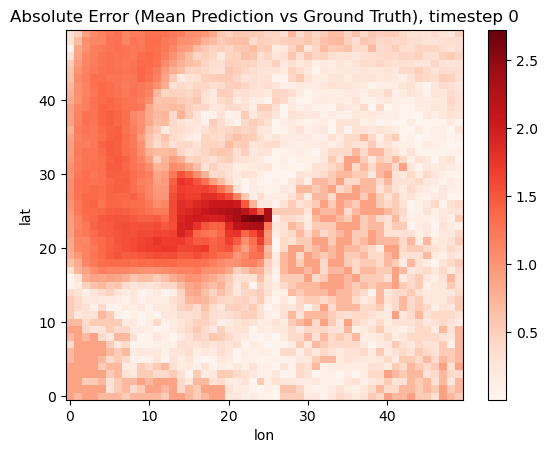

Saved abs_error.png


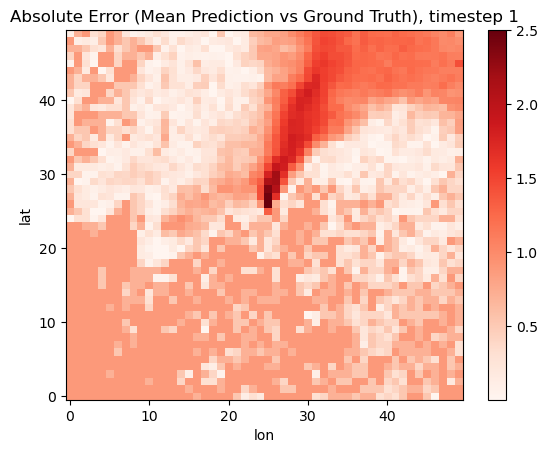

Saved abs_error.png


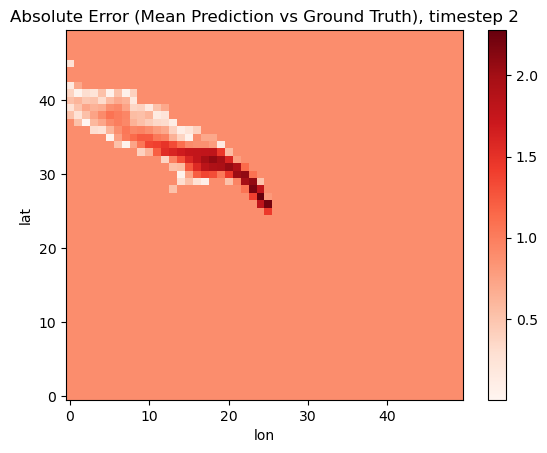

Saved abs_error.png


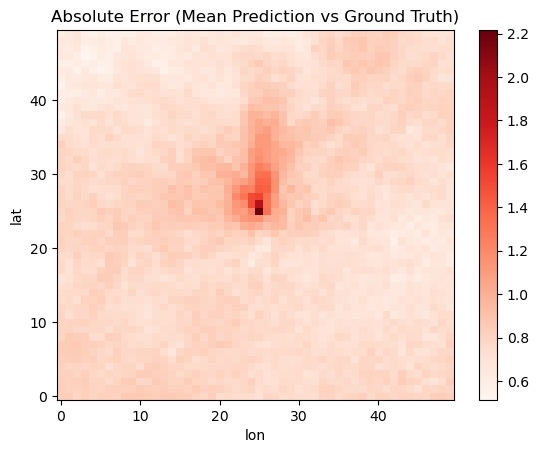

Saved abs_error.png


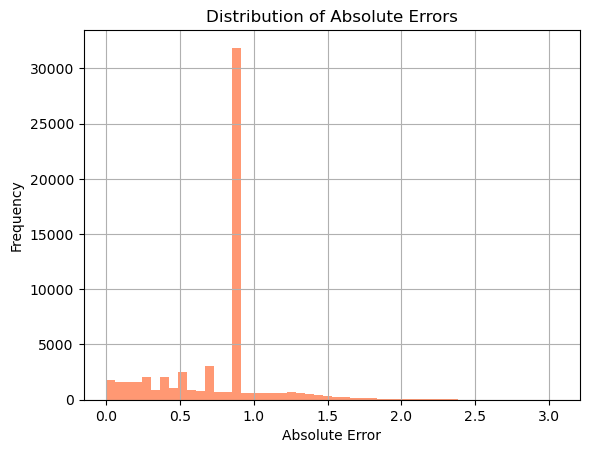

Saved hist_abs_error.png
Pearson correlation between uncertainty and error: -0.029 (p=5.67e-13)


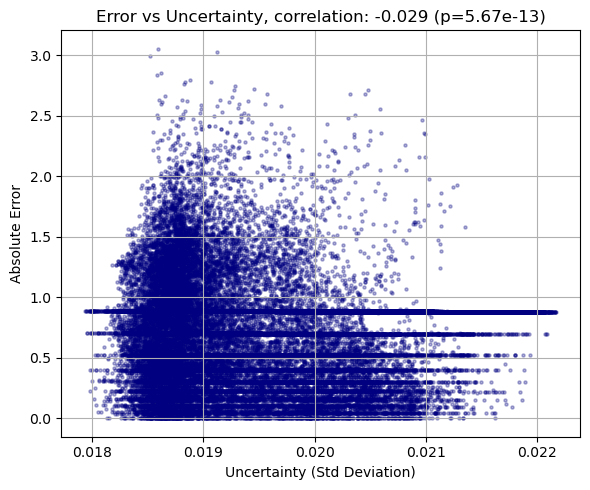

Saved scatter_error_vs_uncertainty.png


In [40]:
# Plot absolute error


for time_step in time_steps:
    plt.figure()
    abs_error.isel(time=time_step).plot.imshow(cmap="Reds")
    plt.title(f"Absolute Error (Mean Prediction vs Ground Truth), timestep {time_step}")
    plt.savefig(save_path(f"abs_error_time_{time_step}.png"))
    plt.show()
    plt.close()
    print("Saved abs_error.png")

# And average error
plt.figure()
abs_error.mean(dim="time").plot.imshow(cmap="Reds")
plt.title("Absolute Error (Mean Prediction vs Ground Truth)")
plt.savefig(save_path(f"abs_error_average.png"))
plt.show()
plt.close()
print("Saved abs_error.png")

# Histogram of absolute error
plt.figure()
plt.hist(abs_error.values.flatten(), bins=50, color="coral", alpha=0.8)
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig(save_path("hist_abs_error.png"))
plt.show()
plt.close()
print("Saved hist_abs_error.png")

# Error vs uncertainty
# Flatten to 1D arrays
error_values = abs_error.values.flatten()
uncertainty_values = std_pred.values.flatten()

# Filter out NaNs (e.g. ocean regions / cropped regions if applicable)
valid = ~np.isnan(error_values) & ~np.isnan(uncertainty_values)
error_values = error_values[valid]
uncertainty_values = uncertainty_values[valid]

corr, p = pearsonr(uncertainty_values, error_values)
print(f"Pearson correlation between uncertainty and error: {corr:.3f} (p={p:.3g})")

# Create scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(uncertainty_values, error_values, alpha=0.3, s=5, c="navy")
plt.xlabel("Uncertainty (Std Deviation)")
plt.ylabel("Absolute Error")
plt.title(f"Error vs Uncertainty, correlation: {corr:.3f} (p={p:.3g})")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("scatter_error_vs_uncertainty.png"))
plt.show()
plt.close()
print("Saved scatter_error_vs_uncertainty.png")




# Consider both spatial and temporal components

## Temporal uncertainty

## MAE compared to fps

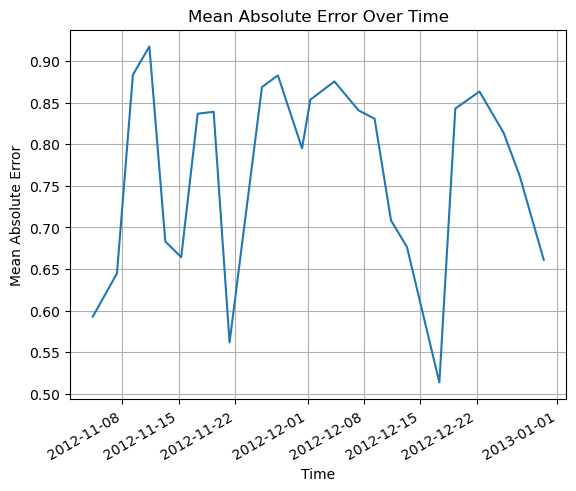

In [43]:
# Mean absolute error across space at each time step
temporal_mae = abs_error.mean(dim=("lat", "lon"))

# Plot
plt.figure()
temporal_mae.plot()
plt.title("Mean Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("temporal_mae.png"))
plt.show()
plt.close()
